In [100]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [101]:
df=pd.read_csv('data/new_stud.csv')

In [102]:
X=df.drop('Total score',axis=1)
y=df['Total score']

In [103]:
num_features=X.select_dtypes(exclude='O').columns
cat_features=X.select_dtypes(include='O').columns

C:\Users\meetp\AppData\Local\Temp\ipykernel_20220\22834786.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=X.select_dtypes(include='O').columns


In [104]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

oh_trans=OneHotEncoder()
scaler=StandardScaler()

ct=ColumnTransformer([
    ('onehot', oh_trans, cat_features),
    ('scaler', scaler, num_features)
])

In [105]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total score,Average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [106]:
X=ct.fit_transform(X)

In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [108]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.851902,0.879264,0.786539,0.881579
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.060110,0.810737,0.720698,0.554098
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.126093,-0.080108,-0.464444,-0.147647
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,-1.259543,-0.765373,-0.069397,-0.732434
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.390024,0.673684,0.918221,0.694447


In [109]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_scores(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, mae, r2

In [110]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import AdaBoostRegressor

In [111]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "XGBoost": XGBRegressor(),
    "CatBoost": CatBoostRegressor(),
    "AdaBoost": AdaBoostRegressor()
}

In [112]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = calculate_scores(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = calculate_scores(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- R2 Score: 1.0000


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.8232
- Mean Absolute Error: 1.0562
- R2 Score: 0.9994
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.8870
- Mean Absolute Error: 1.2605
- R2 Score: 0.9994


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.0163
- Mean Absolute Error: 0.0004
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0173
- Mean Absolute Error: 0.0005
- R2 Score: 1.0000


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 4.6086
- Mean Absolute Error: 35.9273
- R2 Score: 0.9792
----------------------

In [113]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,1.000000
2,Ridge,1.000000
1,Lasso,0.999379
4,Decision Tree,0.998208
5,Random Forest Regressor,0.996653
6,XGBRegressor,0.996039
7,CatBoosting Regressor,0.994527
8,AdaBoost Regressor,0.988803
3,K-Neighbors Regressor,0.967808


In [114]:
lin_model=LinearRegression()
lin_model.fit(X_train, y_train)
y_pred= lin_model.predict(X_test)

In [115]:
pd.DataFrame({'Actual value':y_test, 'Predicted value':y_test_pred, 'Difference':y_test - y_test_pred}).head(10)

,Actual value,Predicted value,Difference
521,261,257.149425,3.850575
737,192,199.395161,-7.395161
740,225,226.038462,-1.038462
660,224,226.038462,-2.038462
411,245,245.721154,-0.721154
678,234,231.898305,2.101695
626,202,202.417266,-0.417266
513,177,172.793103,4.206897
859,232,231.898305,0.101695
136,146,148.445545,-2.445545


<Axes: xlabel='Total score'>

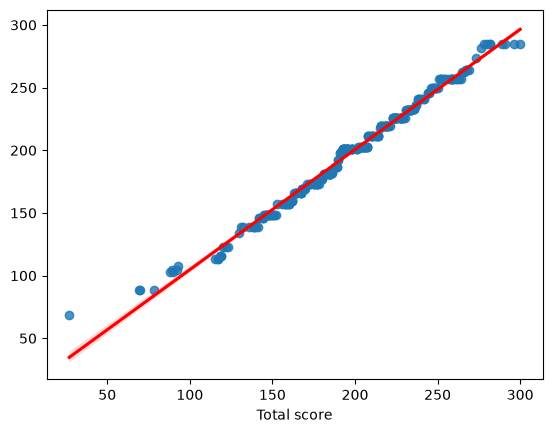

In [117]:
import seaborn as sns
sns.regplot(x=y_test, y=y_test_pred, line_kws={"color":"red"})